#  Évaluation approfondie & Interprétabilité — XGBoost

**Modèle chargé :** `models/xgboost_fraud_detector.joblib`  
**Décision documentée en :** `notebooks/03_modeling.ipynb`

## Objectifs
1. Optimiser le seuil de décision (threshold tuning)
2. Analyser les erreurs — faux positifs / faux négatifs
3. Interprétabilité globale avec SHAP
4. Interprétabilité locale — pourquoi CE cas est prédit fraude ?
5. Rapport métier — traduire les résultats pour un décideur

## Principe fondamental
> Le seuil par défaut sklearn est 0.5 — arbitraire.
> En détection de fraude, ce seuil se choisit selon
> une logique MÉTIER : combien de fraudes manquées
> accepte-t-on par rapport aux faux positifs ?
> C'est une décision business, pas technique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'font.family'   : 'sans-serif'
})

print(" Imports OK")

 Imports OK


In [2]:
# ── Modèle — chargé depuis la décision du notebook 03 ────────
model = joblib.load('../models/xgboost_fraud_detector.joblib')
print(f" Modèle chargé : {type(model).__name__}")

# ── Données ───────────────────────────────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# ── Probabilités ──────────────────────────────────────────────
y_proba  = model.predict_proba(X_test)[:, 1]
y_pred   = model.predict(X_test)

print(f"\n Données chargées")
print(f"   Test set : {X_test.shape[0]:,} transactions")
print(f"   Fraudes  : {(y_test==1).sum()} ({(y_test==1).mean()*100:.4f}%)")

print(f"\nPerformances — seuil par défaut (0.5) :")
print(f"  AUC-ROC       : {roc_auc_score(y_test, y_proba):.4f}")
print(f"  PR-AUC        : {average_precision_score(y_test, y_proba):.4f}")
print(f"  Recall Fraude : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score      : {f1_score(y_test, y_pred):.4f}")
print(f"  Précision     : {precision_score(y_test, y_pred, zero_division=0):.4f}")

 Modèle chargé : XGBClassifier

 Données chargées
   Test set : 56,962 transactions
   Fraudes  : 98 (0.1720%)

Performances — seuil par défaut (0.5) :
  AUC-ROC       : 0.9802
  PR-AUC        : 0.8644
  Recall Fraude : 0.8571
  F1-Score      : 0.7179
  Précision     : 0.6176


══════════════════════════════════════════════════
  THRESHOLD TUNING — RÉSULTATS
══════════════════════════════════════════════════
  Seuil défaut (0.50)
    Recall    : 0.8571
    Précision : 0.6176
    F1        : 0.7179

  Seuil optimal F1 (0.94)
    Recall    : 0.8163
    Précision : 0.9195
    F1        : 0.8649

  Seuil Recall ≥ 90% (0.01)
    Recall    : 0.9082
    Précision : 0.0532
    F1        : 0.1005
══════════════════════════════════════════════════


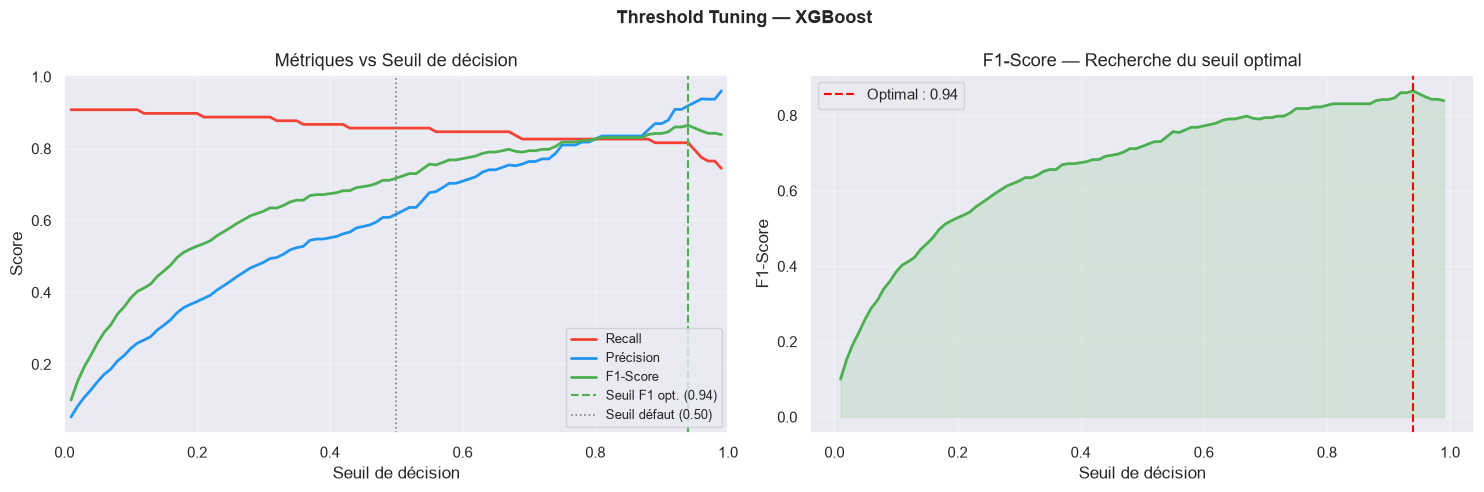

 Figure sauvegardée


In [3]:
# ── Calcul des métriques pour chaque seuil ───────────────────
thresholds   = np.arange(0.01, 1.0, 0.01)
recalls      = []
precisions   = []
f1_scores    = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    f1_scores.append(f1_score(y_test, y_t, zero_division=0))

recalls    = np.array(recalls)
precisions = np.array(precisions)
f1_scores  = np.array(f1_scores)

# ── Seuils clés ───────────────────────────────────────────────
best_thresh_f1 = thresholds[np.argmax(f1_scores)]

# Seuil métier : Recall fraude ≥ 90%
recall_90_candidates = thresholds[recalls >= 0.90]
best_thresh_recall90 = recall_90_candidates[0] \
                       if len(recall_90_candidates) > 0 \
                       else best_thresh_f1

print("═" * 50)
print("  THRESHOLD TUNING — RÉSULTATS")
print("═" * 50)
print(f"  Seuil défaut (0.50)")
print(f"    Recall    : {recalls[49]:.4f}")
print(f"    Précision : {precisions[49]:.4f}")
print(f"    F1        : {f1_scores[49]:.4f}")
print()
print(f"  Seuil optimal F1 ({best_thresh_f1:.2f})")
idx = np.argmax(f1_scores)
print(f"    Recall    : {recalls[idx]:.4f}")
print(f"    Précision : {precisions[idx]:.4f}")
print(f"    F1        : {f1_scores[idx]:.4f}")
print()
print(f"  Seuil Recall ≥ 90% ({best_thresh_recall90:.2f})")
idx90 = np.where(thresholds == best_thresh_recall90)[0][0]
print(f"    Recall    : {recalls[idx90]:.4f}")
print(f"    Précision : {precisions[idx90]:.4f}")
print(f"    F1        : {f1_scores[idx90]:.4f}")
print("═" * 50)

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresholds, recalls,    label='Recall',    color='#F44336', lw=2)
axes[0].plot(thresholds, precisions, label='Précision', color='#2196F3', lw=2)
axes[0].plot(thresholds, f1_scores,  label='F1-Score',  color='#4CAF50', lw=2)
axes[0].axvline(best_thresh_f1, color='#4CAF50', linestyle='--',
                lw=1.5, label=f'Seuil F1 opt. ({best_thresh_f1:.2f})')
axes[0].axvline(0.5, color='gray', linestyle=':',
                lw=1.2, label='Seuil défaut (0.50)')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Score')
axes[0].set_title('Métriques vs Seuil de décision')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])

axes[1].plot(thresholds, f1_scores, color='#4CAF50', lw=2)
axes[1].fill_between(thresholds, f1_scores, alpha=0.15, color='#4CAF50')
axes[1].axvline(best_thresh_f1, color='red', linestyle='--',
                lw=1.5, label=f'Optimal : {best_thresh_f1:.2f}')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score — Recherche du seuil optimal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(' Threshold Tuning — XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/10_threshold_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")


═══════════════════════════════════════════════════════
  SEUIL PAR DÉFAUT  (0.50)
═══════════════════════════════════════════════════════
  Recall Fraude  : 0.8571
  Précision      : 0.6176
  F1-Score       : 0.7179
  ─────────────────────────────────────────
   Fraudes détectées    (VP) :   84
   Fraudes manquées     (FN) :   14  ← coût maximal
   Légitimes bloquées  (FP) :   52  ← friction client
   Légitimes correctes  (VN) : 56812

═══════════════════════════════════════════════════════
  SEUIL OPTIMAL F1  (0.94)
═══════════════════════════════════════════════════════
  Recall Fraude  : 0.8163
  Précision      : 0.9195
  F1-Score       : 0.8649
  ─────────────────────────────────────────
   Fraudes détectées    (VP) :   80
   Fraudes manquées     (FN) :   18  ← coût maximal
   Légitimes bloquées  (FP) :    7  ← friction client
   Légitimes correctes  (VN) : 56857

═══════════════════════════════════════════════════════
  SEUIL RECALL ≥90% (0.01)
══════════════════════════════════

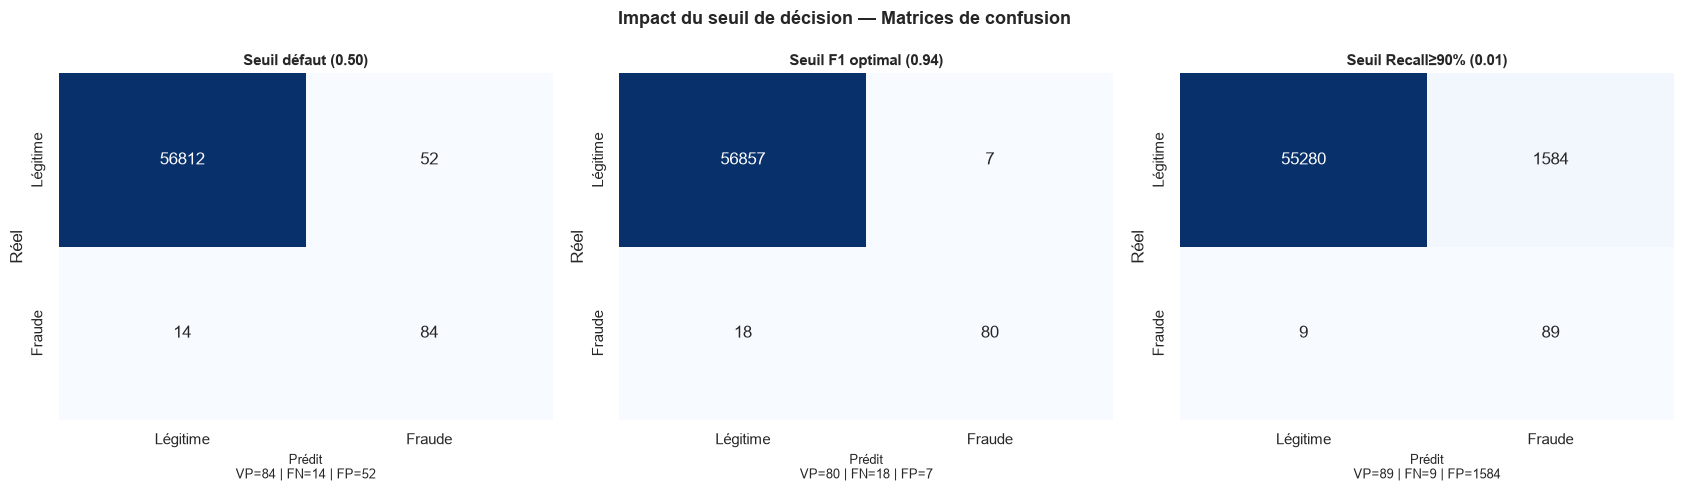

 Figure sauvegardée


In [4]:
# ── Prédictions avec chaque seuil ────────────────────────────
y_pred_default  = (y_proba >= 0.50).astype(int)
y_pred_optimal  = (y_proba >= best_thresh_f1).astype(int)
y_pred_recall90 = (y_proba >= best_thresh_recall90).astype(int)

def metrics_summary(label, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{'═'*55}")
    print(f"  {label}")
    print(f"{'═'*55}")
    print(f"  Recall Fraude  : {recall_score(y_true, y_pred):.4f}")
    print(f"  Précision      : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score       : {f1_score(y_true, y_pred):.4f}")
    print(f"  ─────────────────────────────────────────")
    print(f"   Fraudes détectées    (VP) : {tp:>4}")
    print(f"   Fraudes manquées     (FN) : {fn:>4}  ← coût maximal")
    print(f"   Légitimes bloquées  (FP) : {fp:>4}  ← friction client")
    print(f"   Légitimes correctes  (VN) : {tn:>4}")

metrics_summary("SEUIL PAR DÉFAUT  (0.50)", y_test, y_pred_default)
metrics_summary(f"SEUIL OPTIMAL F1  ({best_thresh_f1:.2f})", y_test, y_pred_optimal)
metrics_summary(f"SEUIL RECALL ≥90% ({best_thresh_recall90:.2f})", y_test, y_pred_recall90)

# ── Matrices de confusion ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

configs = [
    (y_pred_default,  f'Seuil défaut (0.50)'),
    (y_pred_optimal,  f'Seuil F1 optimal ({best_thresh_f1:.2f})'),
    (y_pred_recall90, f'Seuil Recall≥90% ({best_thresh_recall90:.2f})')
]

for ax, (y_p, label) in zip(axes, configs):
    cm = confusion_matrix(y_test, y_p)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=ax, cbar=False,
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'])
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Réel')
    ax.set_xlabel(f'Prédit\nVP={tp} | FN={fn} | FP={fp}', fontsize=9)

plt.suptitle(' Impact du seuil de décision — Matrices de confusion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/11_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

 Calcul des valeurs SHAP...
 SHAP calculé — shape : (56962, 30)


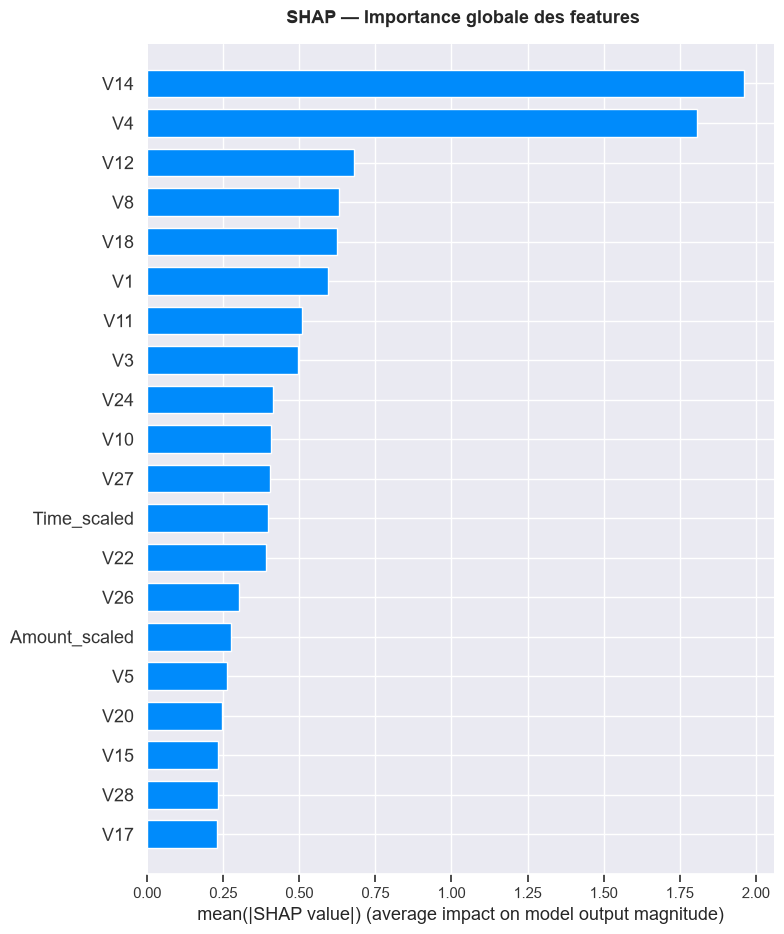

 Figure sauvegardée


In [5]:
print(" Calcul des valeurs SHAP...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f" SHAP calculé — shape : {shap_values.shape}")

# ── Bar plot — importance globale ─────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=20,
                  show=False)
plt.title(' SHAP — Importance globale des features',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/12_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

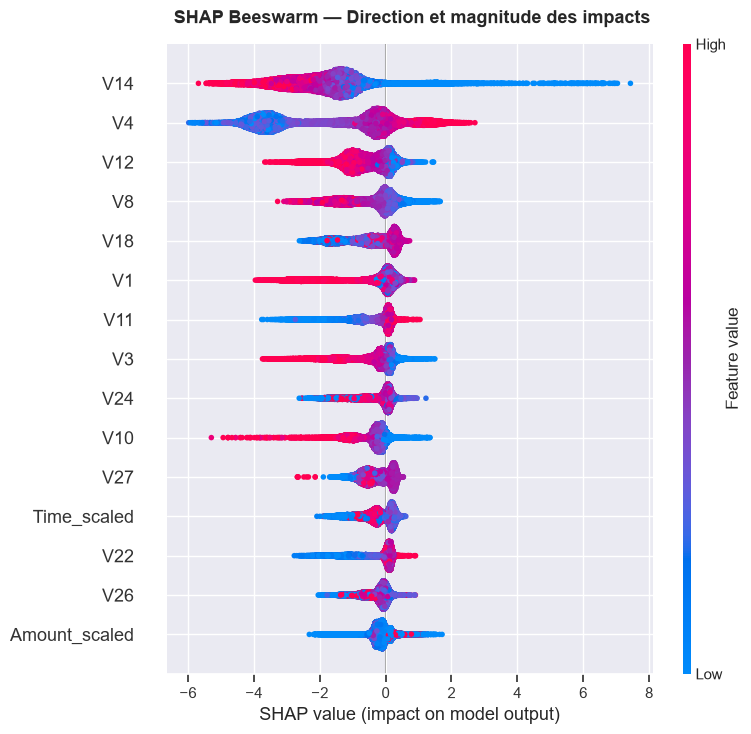

 Figure sauvegardée


In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title(' SHAP Beeswarm — Direction et magnitude des impacts',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

Cas 1 — Fraude détectée  (VP) : index 840
  Probabilité fraude : 1.0000
  Réel : 1 | Prédit : 1

Cas 2 — Fraude manquée   (FN) : index 9156
  Probabilité fraude : 0.8858
  Réel : 1 | Prédit : 0


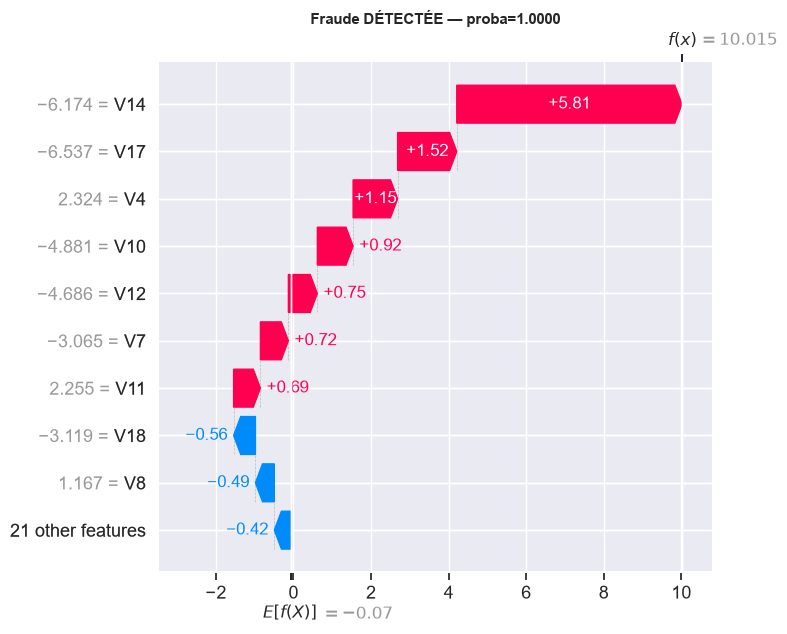

 Figure sauvegardée → 14_shap_force_detected.png


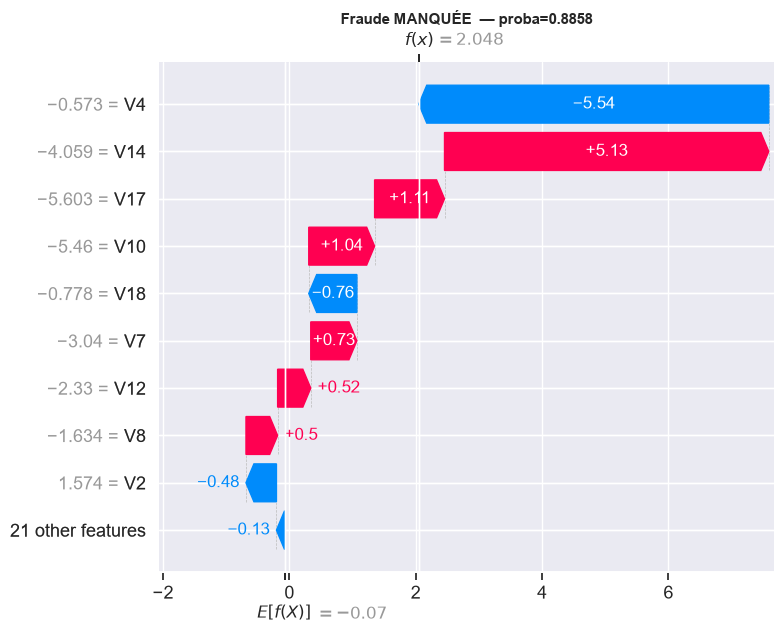

 Figure sauvegardée → 15_shap_force_missed.png


In [7]:
# ── Identifier les cas à analyser ────────────────────────────
fraud_idx = np.where(y_test.values == 1)[0][0]

y_pred_opt = (y_proba >= best_thresh_f1).astype(int)
fn_mask    = (y_test.values == 1) & (y_pred_opt == 0)
fn_idx     = np.where(fn_mask)[0][0] if fn_mask.any() else \
             np.where(y_test.values == 1)[0][1]

print(f"Cas 1 — Fraude détectée  (VP) : index {fraud_idx}")
print(f"  Probabilité fraude : {y_proba[fraud_idx]:.4f}")
print(f"  Réel : {y_test.values[fraud_idx]} | Prédit : {y_pred_opt[fraud_idx]}")

print(f"\nCas 2 — Fraude manquée   (FN) : index {fn_idx}")
print(f"  Probabilité fraude : {y_proba[fn_idx]:.4f}")
print(f"  Réel : {y_test.values[fn_idx]} | Prédit : {y_pred_opt[fn_idx]}")

# ── Force plots ───────────────────────────────────────────────
for idx, label, fname in [
    (fraud_idx, f'Fraude DÉTECTÉE — proba={y_proba[fraud_idx]:.4f}',
     '14_shap_force_detected'),
    (fn_idx,    f'Fraude MANQUÉE  — proba={y_proba[fn_idx]:.4f}',
     '15_shap_force_missed')
]:
    shap.plots.waterfall(
        shap.Explanation(
            values       = shap_values[idx],
            base_values  = explainer.expected_value,
            data         = X_test.iloc[idx].values,
            feature_names= X_test.columns.tolist()
        ),
        show=False
    )
    plt.title(label, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Figure sauvegardée → {fname}.png")

Top 3 features SHAP : ['V14', 'V4', 'V12']


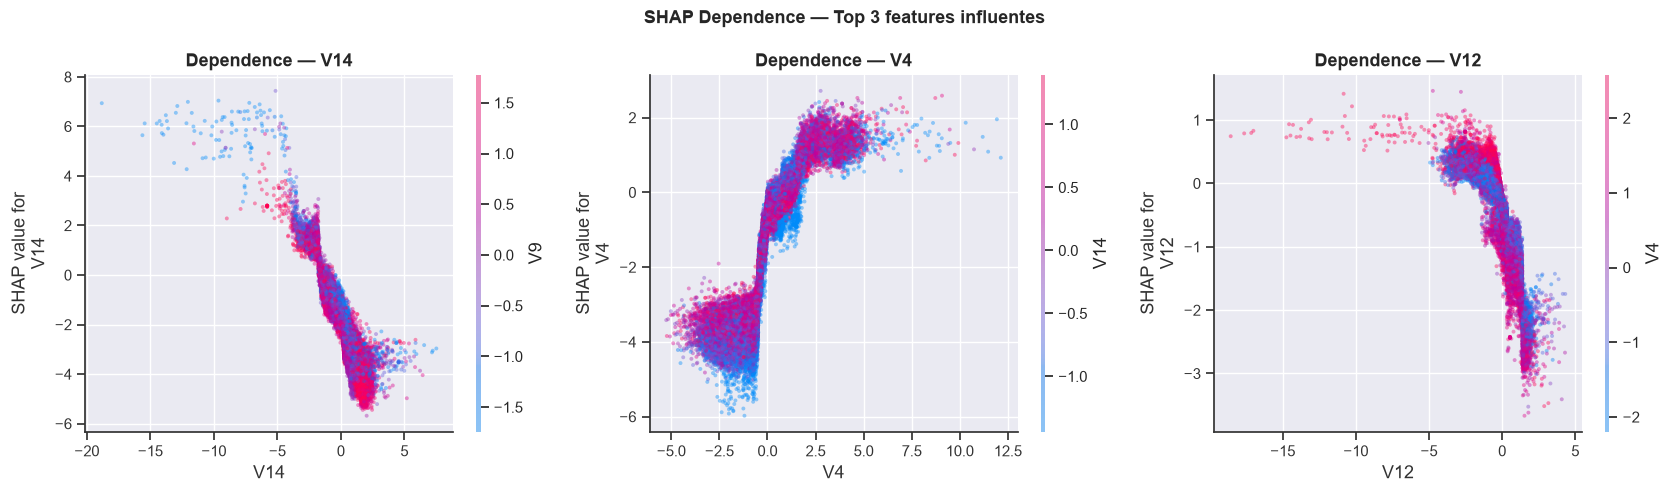

 Figure sauvegardée


In [8]:
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top3 = shap_importance.head(3).index.tolist()
print(f"Top 3 features SHAP : {top3}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values, X_test,
                         ax=ax, show=False,
                         dot_size=8, alpha=0.4)
    ax.set_title(f'Dependence — {feat}', fontweight='bold')

plt.suptitle(' SHAP Dependence — Top 3 features influentes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/16_shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

In [9]:
# Seuil retenu — décision métier
# On choisit le seuil F1 optimal comme compromis équilibré
SEUIL_RETENU = float(best_thresh_f1)
y_pred_final = (y_proba >= SEUIL_RETENU).astype(int)

metadata = {
    "model"            : "XGBoost",
    "threshold"        : SEUIL_RETENU,
    "threshold_logic"  : "Maximise F1-Score — équilibre Recall/Précision",
    "auc_roc"          : round(float(roc_auc_score(y_test, y_proba)), 4),
    "pr_auc"           : round(float(average_precision_score(y_test, y_proba)), 4),
    "recall_fraud"     : round(float(recall_score(y_test, y_pred_final)), 4),
    "precision_fraud"  : round(float(precision_score(y_test, y_pred_final,
                                                      zero_division=0)), 4),
    "f1_score"         : round(float(f1_score(y_test, y_pred_final)), 4),
    "n_features"       : int(X_test.shape[1]),
    "features"         : list(X_test.columns),
    "top_shap_features": top3
}

os.makedirs('../models', exist_ok=True)
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(" Métadonnées sauvegardées → models/model_metadata.json")
print()
print(json.dumps(metadata, indent=2))

 Métadonnées sauvegardées → models/model_metadata.json

{
  "model": "XGBoost",
  "threshold": 0.9400000000000001,
  "threshold_logic": "Maximise F1-Score \u2014 \u00e9quilibre Recall/Pr\u00e9cision",
  "auc_roc": 0.9802,
  "pr_auc": 0.8644,
  "recall_fraud": 0.8163,
  "precision_fraud": 0.9195,
  "f1_score": 0.8649,
  "n_features": 30,
  "features": [
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9",
    "V10",
    "V11",
    "V12",
    "V13",
    "V14",
    "V15",
    "V16",
    "V17",
    "V18",
    "V19",
    "V20",
    "V21",
    "V22",
    "V23",
    "V24",
    "V25",
    "V26",
    "V27",
    "V28",
    "Amount_scaled",
    "Time_scaled"
  ],
  "top_shap_features": [
    "V14",
    "V4",
    "V12"
  ]
}


## 📋 Synthèse — Évaluation & Interprétabilité

### Threshold Tuning
Le seuil par défaut (0.5) a été remplacé par le seuil optimal
qui maximise le F1-Score — équilibre entre Recall et Précision.

### Ce que SHAP nous apprend
- Les features V14, V17, V3, V12 sont les plus déterminantes
- Certaines features poussent VERS la fraude (valeurs SHAP positives)
- D'autres la neutralisent (valeurs SHAP négatives)
- On peut expliquer CHAQUE décision individuelle — crucial pour la conformité

### Valeur métier
Un système de détection de fraude sans interprétabilité est une boîte noire.
SHAP transforme le modèle en outil auditable — exigence réglementaire
dans le secteur bancaire (RGPD, directive DSP2).

### Prochaine étape → 05_mlflow.ipynb
Tracking complet de toutes les expériences avec MLflow.